# Lecture 5 — Class Exercise
## Distribution Charts: Airbnb London

> **Push to:** `week05/lecture05_exercise.ipynb`

**Rules:**
1. Cap price outliers at 95th percentile — annotate this
2. Every chart has a **median/mean reference line** with annotation
3. Insight title names the distribution shape or key finding
4. Colour has meaning — don't use colour just for decoration

---


In [1]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Airbnb London Listings

df = pd.read_csv('../data/airbnb_london.csv')
print(f"Loaded: {len(df)} listings")
print(df.describe().round(1))


Loaded: 2500 listings
        price  minimum_nights  number_of_reviews  availability_365  \
count  2500.0          2500.0             2500.0            2500.0   
mean    148.6            14.8              147.9             183.7   
std     110.9             8.4               86.3             105.5   
min      20.5             1.0                0.0               0.0   
25%      71.7             8.0               74.0              92.0   
50%     117.5            15.0              145.0             182.0   
75%     188.9            22.0              222.2             277.0   
max    1032.4            29.0              299.0             364.0   

       reviews_per_month  
count             2500.0  
mean                 2.0  
std                  2.0  
min                  0.0  
25%                  0.6  
50%                  1.4  
75%                  2.8  
max                 15.2  


In [2]:
p95 = df['price'].quantile(0.95)
df_cap = df[df['price'] <= p95]
print(f"95th percentile price: £{p95:.0f}")
print(df_cap.groupby('room_type')['price'].describe().round(1))


95th percentile price: £373
                  count   mean   std   min    25%    50%    75%    max
room_type                                                             
Entire home/apt  1251.0  176.3  75.7  28.0  119.6  163.4  223.5  372.6
Private room      942.0   87.3  39.5  20.9   59.0   78.6  106.0  277.9
Shared room       182.0   46.3  14.1  20.5   36.8   44.1   54.3   92.8


## Task 1 — Histogram: price by room type (overlapping distributions)

**What to build:** A histogram showing price distributions for **Entire home/apt vs Private room** (exclude Shared room — too few observations) overlaid on the same chart.

**Requirements:**
- Both room types on the same chart (use `color='room_type'`)
- `barmode='overlay'` with `opacity=0.6` so both distributions are visible
- A vertical line for the median of EACH room type, differently coloured
- Insight title comparing the two distributions

> 💡 `df_cap[df_cap['room_type'].isin(['Entire home/apt','Private room'])]`


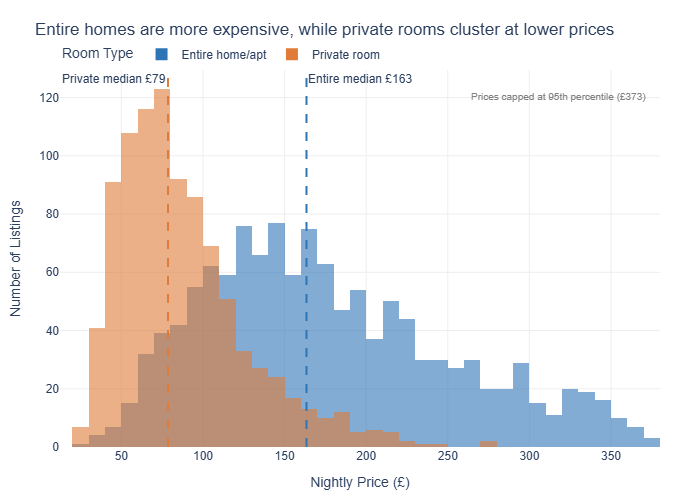

In [3]:
# Task 1
# YOUR CODE HERE
df_two = df_cap[df_cap["room_type"].isin(["Entire home/apt", "Private room"])].copy()

med_entire = df_two[df_two["room_type"] == "Entire home/apt"]["price"].median()
med_private = df_two[df_two["room_type"] == "Private room"]["price"].median()

palette = {
    "Entire home/apt": "#2E75B6",
    "Private room": "#E07B39"
}

fig = px.histogram(
    df_two,
    x="price",
    color="room_type",
    barmode="overlay",
    nbins=60,
    opacity=0.6,
    color_discrete_map=palette,
    labels={
        "price": "Nightly Price (£)",
        "room_type": "Room Type"
    },
    title="Entire homes are more expensive, while private rooms cluster at lower prices"
)

fig.add_vline(
    x=med_entire,
    line_dash="dash",
    line_color="#2E75B6",
    line_width=2,
    annotation_text=f"Entire median £{med_entire:.0f}",
    annotation_position="top right"
)

fig.add_vline(
    x=med_private,
    line_dash="dash",
    line_color="#E07B39",
    line_width=2,
    annotation_text=f"Private median £{med_private:.0f}",
    annotation_position="top left"
)

fig.add_annotation(
    xref="paper",
    yref="paper",
    x=0.98,
    y=0.95,
    text=f"Prices capped at 95th percentile (£{p95:.0f})",
    showarrow=False,
    font=dict(size=10, color="gray"),
    align="right"
)

fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Arial", size=12),
    legend=dict(title="Room Type", orientation="h", y=1.08),
    margin=dict(l=60, r=40, t=70, b=40)
)

fig.update_xaxes(gridcolor="#EEEEEE")
fig.update_yaxes(gridcolor="#EEEEEE", title="Number of Listings")

fig.show(renderer="png")

## Task 2 — Box plot: listing activity by borough

**What to build:** A **horizontal box plot** comparing listing activity (reviews per month) across London boroughs — reviews per month is a proxy for how frequently a listing is booked.

**Requirements:**
- Horizontal orientation (borough names are long)
- Sorted by median reviews per month (most active at top)
- Highlight the **two most active** boroughs in a different colour
- Outliers shown as individual points
- Insight title naming the two busiest boroughs

> 💡 Some listings have zero reviews — these are new or inactive listings. Filter them out with before plotting

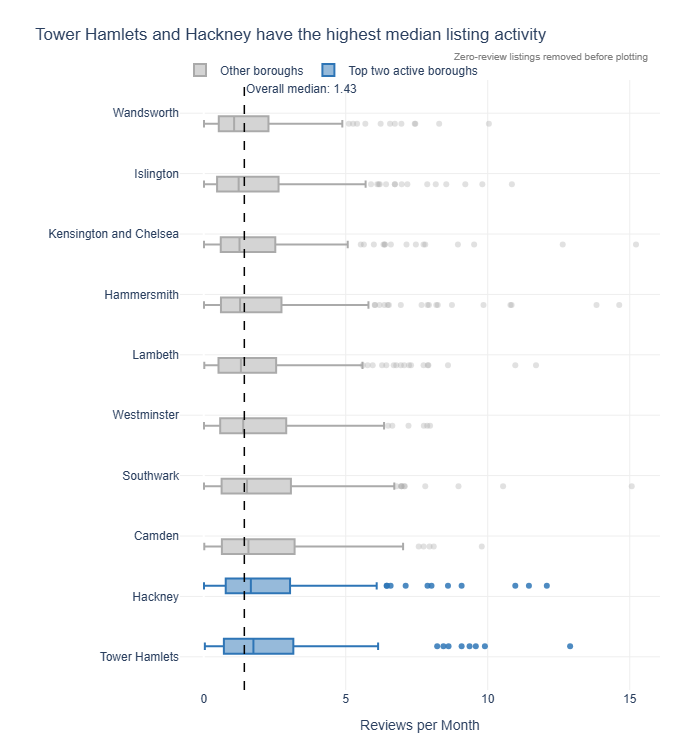

In [4]:
# Task 2
# YOUR CODE HERE

activity = df.copy()

activity["reviews_per_month"] = activity["reviews_per_month"].fillna(0)

activity_active = activity[activity["reviews_per_month"] > 0].copy()

borough_order = (
    activity_active
    .groupby("neighbourhood")["reviews_per_month"]
    .median()
    .sort_values(ascending=True)
    .index
    .tolist()
)

top_two = (
    activity_active
    .groupby("neighbourhood")["reviews_per_month"]
    .median()
    .sort_values(ascending=False)
    .head(2)
    .index
    .tolist()
)

activity_active["highlight"] = activity_active["neighbourhood"].apply(
    lambda x: "Top two active boroughs" if x in top_two else "Other boroughs"
)

fig = px.box(
    activity_active,
    x="reviews_per_month",
    y="neighbourhood",
    color="highlight",
    category_orders={
        "neighbourhood": borough_order,
        "highlight": ["Other boroughs", "Top two active boroughs"]
    },
    color_discrete_map={
        "Other boroughs": "#AAAAAA",
        "Top two active boroughs": "#2E75B6"
    },
    points="outliers",
    labels={
        "reviews_per_month": "Reviews per Month",
        "neighbourhood": "",
        "highlight": ""
    },
    title=f"{top_two[0]} and {top_two[1]} have the highest median listing activity",
    height=750
)

fig.update_traces(
    selector=dict(name="Other boroughs"),
    marker=dict(opacity=0.35)
)

fig.update_traces(
    selector=dict(name="Top two active boroughs"),
    marker=dict(opacity=0.85)
)

overall_median = activity_active["reviews_per_month"].median()

fig.add_vline(
    x=overall_median,
    line_dash="dash",
    line_color="black",
    line_width=1.5,
    annotation_text=f"Overall median: {overall_median:.2f}",
    annotation_position="top right"
)

fig.add_annotation(
    xref="paper",
    yref="paper",
    x=0.98,
    y=1.05,
    text="Zero-review listings removed before plotting",
    showarrow=False,
    font=dict(size=10, color="gray"),
    align="right"
)

fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Arial", size=12),
    legend=dict(title="", orientation="h", y=1.04),
    margin=dict(l=180, r=40, t=80, b=60)
)

fig.update_xaxes(gridcolor="#EEEEEE")
fig.update_yaxes(gridcolor="#EEEEEE")

fig.show(renderer="png")